In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set(style="whitegrid")

# Load the dataset
# This path should be correct based on your file structure
file_path = 'data/vehicle_maintenance_data.csv' 
df = pd.read_csv(file_path)

# --- First Inspection ---

# See the first 5 rows
print("--- First 5 Rows ---")
print(df.head())

# Get a summary of all columns (data types, non-null counts)
print("\n--- Data Info ---")
df.info()

# Get basic descriptive statistics (mean, std, min, max, etc.)
print("\n--- Descriptive Statistics ---")
print(df.describe())

# Check for missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

--- First 5 Rows ---
  Vehicle_Model  Mileage Maintenance_History  Reported_Issues  Vehicle_Age  \
0         Truck    58765                Good                0            4   
1           Van    60353             Average                1            7   
2           Bus    68072                Poor                0            2   
3           Bus    60849             Average                4            5   
4           Bus    45742                Poor                5            1   

  Fuel_Type Transmission_Type  Engine_Size  Odometer_Reading  \
0  Electric         Automatic         2000             28524   
1  Electric         Automatic         2500            133630   
2  Electric         Automatic         1500             34022   
3    Petrol         Automatic         2500             81636   
4    Petrol            Manual         2000             97162   

  Last_Service_Date Warranty_Expiry_Date Owner_Type  Insurance_Premium  \
0        2023-11-23           2025-06-24     Second


--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Vehicle_Model         50000 non-null  object 
 1   Mileage               50000 non-null  int64  
 2   Maintenance_History   50000 non-null  object 
 3   Reported_Issues       50000 non-null  int64  
 4   Vehicle_Age           50000 non-null  int64  
 5   Fuel_Type             50000 non-null  object 
 6   Transmission_Type     50000 non-null  object 
 7   Engine_Size           50000 non-null  int64  
 8   Odometer_Reading      50000 non-null  int64  
 9   Last_Service_Date     50000 non-null  object 
 10  Warranty_Expiry_Date  50000 non-null  object 
 11  Owner_Type            50000 non-null  object 
 12  Insurance_Premium     50000 non-null  int64  
 13  Service_History       50000 non-null  int64  
 14  Accident_History      50000 non-null  int64  
 15  

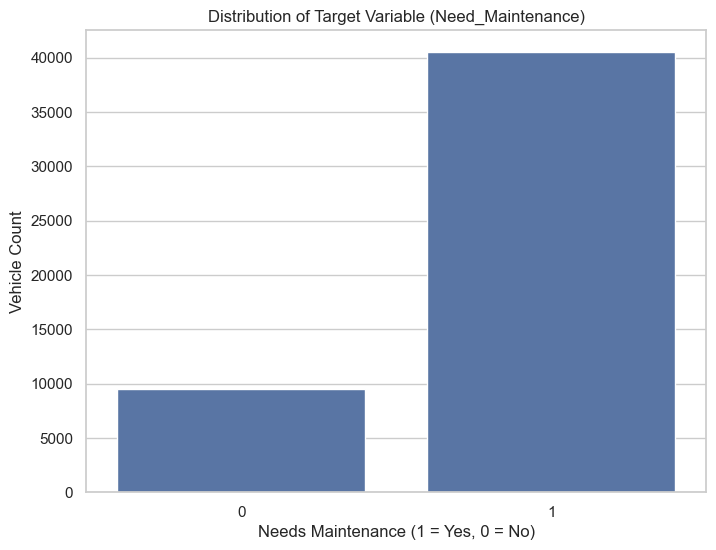

In [2]:
# --- Step 2: Check Data Types, Missing Values, and Target Variable ---

# 1. Get a summary of all columns (data types, non-null counts)
print("\n--- Data Info ---")
df.info()

# 2. Check for missing values
print("\n--- Missing Values Count ---")
print(df.isnull().sum())

# 3. Analyze the target variable 'Need_Maintenance'
print("\n--- Target Variable Distribution ---")
print(df['Need_Maintenance'].value_counts())

# 4. Visualize the target variable distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Need_Maintenance', data=df)
plt.title('Distribution of Target Variable (Need_Maintenance)')
plt.xlabel('Needs Maintenance (1 = Yes, 0 = No)')
plt.ylabel('Vehicle Count')
plt.show()


--- Target Variable Distribution ---
Need_Maintenance
1    40498
0     9502
Name: count, dtype: int64

Percentage Distribution:
Need_Maintenance
1    80.996
0    19.004
Name: proportion, dtype: float64


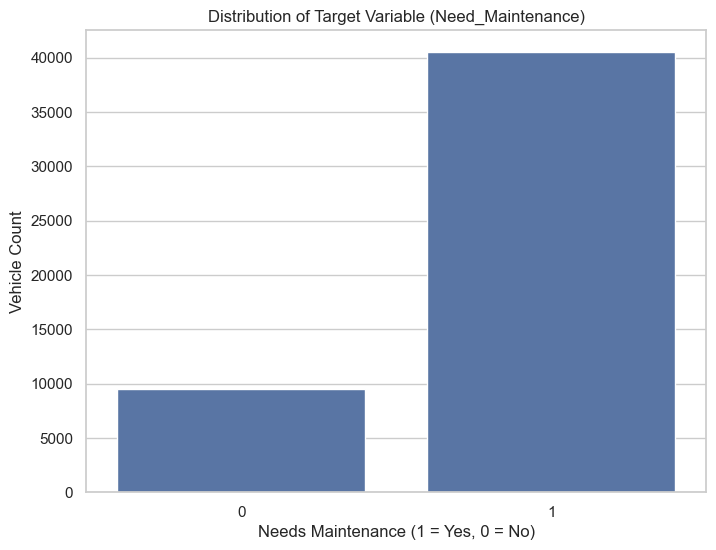


--- Unique Values in Object Columns ---

--- Column: Vehicle_Model ---
Number of Unique Values: 6
Values: ['Truck' 'Van' 'Bus' 'Motorcycle' 'SUV' 'Car']

--- Column: Maintenance_History ---
Number of Unique Values: 3
Values: ['Good' 'Average' 'Poor']

--- Column: Fuel_Type ---
Number of Unique Values: 3
Values: ['Electric' 'Petrol' 'Diesel']

--- Column: Transmission_Type ---
Number of Unique Values: 2
Values: ['Automatic' 'Manual']

--- Column: Owner_Type ---
Number of Unique Values: 3
Values: ['Second' 'First' 'Third']

--- Column: Tire_Condition ---
Number of Unique Values: 3
Values: ['New' 'Good' 'Worn Out']

--- Column: Brake_Condition ---
Number of Unique Values: 3
Values: ['New' 'Good' 'Worn Out']

--- Column: Battery_Status ---
Number of Unique Values: 3
Values: ['Weak' 'New' 'Good']


In [3]:
# --- Step 3: Analyze Target Variable & Explore Categorical Features ---

# 1. Analyze the target variable 'Need_Maintenance'
print("\n--- Target Variable Distribution ---")
target_distribution = df['Need_Maintenance'].value_counts()
print(target_distribution)

# Print as percentages
print(f"\nPercentage Distribution:\n{df['Need_Maintenance'].value_counts(normalize=True) * 100}")

# 2. Visualize the target variable distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='Need_Maintenance', data=df)
plt.title('Distribution of Target Variable (Need_Maintenance)')
plt.xlabel('Needs Maintenance (1 = Yes, 0 = No)')
plt.ylabel('Vehicle Count')
plt.show()

# 3. Explore all 'object' type columns (Categorical Features)
print("\n--- Unique Values in Object Columns ---")
# We exclude the date columns for now, we'll handle them separately
object_cols = df.select_dtypes(include=['object']).columns
object_cols = object_cols.drop(['Last_Service_Date', 'Warranty_Expiry_Date'])

for col in object_cols:
    print(f"\n--- Column: {col} ---")
    unique_values = df[col].unique()
    print(f"Number of Unique Values: {len(unique_values)}")
    
    # Print all unique values if there aren't too many
    if len(unique_values) < 20:
         print(f"Values: {unique_values}")
    else:
        # Otherwise just print the first 20
         print(f"Top 20 Values: {unique_values[:20]}")

In [4]:
from datetime import datetime

# --- Step 4: Feature Engineering ---

# 1. Convert date columns to datetime objects
df['Last_Service_Date'] = pd.to_datetime(df['Last_Service_Date'])
df['Warranty_Expiry_Date'] = pd.to_datetime(df['Warranty_Expiry_Date'])

# 2. Engineer new features
# We'll calculate the number of days from "today" (we'll assume 'today' is the max date in the dataset)
# This makes the data relative and avoids issues if this were real-time data.
today_date = datetime.now() 

df['days_since_last_service'] = (today_date - df['Last_Service_Date']).dt.days
df['days_until_warranty_expiry'] = (df['Warranty_Expiry_Date'] - today_date).dt.days

# 3. Drop the original date columns
df_processed = df.drop(['Last_Service_Date', 'Warranty_Expiry_Date'], axis=1)

# Display the new features
print("--- New Date-Based Features ---")
print(df_processed[['days_since_last_service', 'days_until_warranty_expiry']].head())

--- New Date-Based Features ---
   days_since_last_service  days_until_warranty_expiry
0                      709                        -131
1                      772                        -151
2                      858                        -189
3                      800                           3
4                      891                         -49


In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Step 5: Full Preprocessing Pipeline ---

# 1. Define Features (X) and Target (y)
# We use the df_processed (which has our new date features)
# and drop the target variable 'Need_Maintenance' from X
X = df_processed.drop('Need_Maintenance', axis=1)
y = df_processed['Need_Maintenance']

# 2. Split Data into Training and Test Sets
# We use stratify=y to ensure the 81%/19% split is maintained in both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Original data shape: {X.shape}")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")

# --- 3. Define Column Groups ---

# All numeric features that need scaling
numeric_features = [
    'Mileage', 'Reported_Issues', 'Vehicle_Age', 'Engine_Size', 'Odometer_Reading',
    'Insurance_Premium', 'Service_History', 'Accident_History', 'Fuel_Efficiency',
    'days_since_last_service', 'days_until_warranty_expiry'
]

# Nominal (text) features to be One-Hot Encoded
nominal_features = ['Vehicle_Model', 'Fuel_Type']

# Ordinal (text) features to be Ordinally Encoded
ordinal_features = [
    'Maintenance_History', 'Transmission_Type', 'Owner_Type',
    'Tire_Condition', 'Brake_Condition', 'Battery_Status'
]

# Define the specific order for each ordinal feature
# This is crucial for the model to understand the hierarchy
maintenance_order = ['Poor', 'Average', 'Good']
transmission_order = ['Manual', 'Automatic']
owner_order = ['Third', 'Second', 'First']
condition_order = ['Worn Out', 'Good', 'New']
battery_order = ['Weak', 'Good', 'New']

# --- 4. Create the Transformers ---

# Numeric transformer: Scale the data
numeric_transformer = StandardScaler()

# Nominal transformer: One-hot encode
nominal_transformer = OneHotEncoder(handle_unknown='ignore')

# Ordinal transformer: Ordinal encode with our defined orders
ordinal_transformer = OrdinalEncoder(categories=[
    maintenance_order,
    transmission_order,
    owner_order,
    condition_order,
    condition_order,  # Re-using for Brake_Condition
    battery_order
], handle_unknown='error') # We set 'error' to catch any unexpected values

# --- 5. Build the ColumnTransformer ---
# [Image of a data preprocessing pipeline]
# This 'preprocessor' object will apply the correct transformer to the correct column
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)
    ],
    remainder='passthrough' # Keep any columns not listed (though we've listed all)
)

# 6. Apply the preprocessor to our data
# We 'fit' on the training data and 'transform' both
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"\nShape of processed training data: {X_train_processed.shape}")
print("--- Preprocessing Complete! ---")

Original data shape: (50000, 19)
X_train shape: (40000, 19)
X_test shape: (10000, 19)

Shape of processed training data: (40000, 26)
--- Preprocessing Complete! ---


--- Baseline Model (Logistic Regression) ---
                       precision    recall  f1-score   support

   No Maintenance (0)       0.76      0.64      0.69      1900
Needs Maintenance (1)       0.92      0.95      0.93      8100

             accuracy                           0.89     10000
            macro avg       0.84      0.79      0.81     10000
         weighted avg       0.89      0.89      0.89     10000


--- Confusion Matrix ---


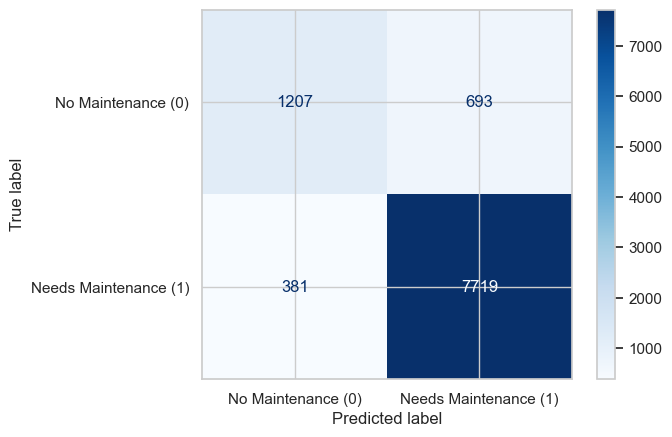

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

# --- Step 6: Baseline Model (Logistic Regression) ---

# 1. Train the model
# We use 'X_train_processed' and 'y_train'
baseline_model = LogisticRegression(random_state=42, max_iter=1000)
baseline_model.fit(X_train_processed, y_train)

# 2. Make predictions on the test set
y_pred_baseline = baseline_model.predict(X_test_processed)

# 3. Show the Classification Report
print("--- Baseline Model (Logistic Regression) ---")
print(classification_report(y_test, y_pred_baseline, target_names=['No Maintenance (0)', 'Needs Maintenance (1)']))

# 4. Show the Confusion Matrix
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Maintenance (0)', 'Needs Maintenance (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

--- Balanced Model (Logistic Regression with class_weight='balanced') ---
                       precision    recall  f1-score   support

   No Maintenance (0)       0.56      0.87      0.68      1900
Needs Maintenance (1)       0.96      0.84      0.90      8100

             accuracy                           0.84     10000
            macro avg       0.76      0.85      0.79     10000
         weighted avg       0.89      0.84      0.85     10000


--- New Confusion Matrix ---


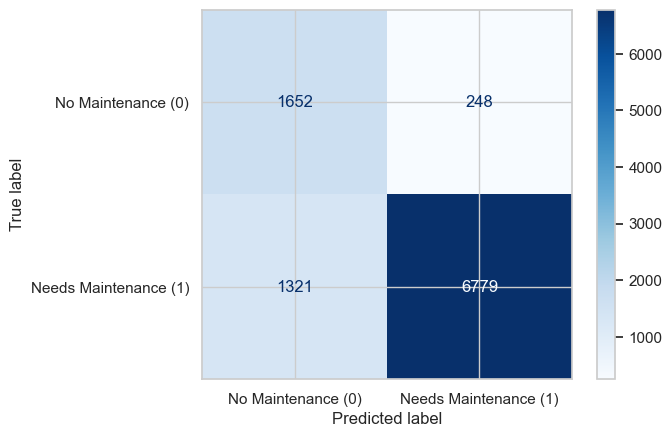

In [7]:
# --- Step 7: Baseline Model with Class Weight Balancing ---

# 1. Train the model with class_weight='balanced'
# This tells the model to penalize mistakes on the minority class (0) more heavily
balanced_model = LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced')
balanced_model.fit(X_train_processed, y_train)

# 2. Make predictions on the test set
y_pred_balanced = balanced_model.predict(X_test_processed)

# 3. Show the new Classification Report
print("--- Balanced Model (Logistic Regression with class_weight='balanced') ---")
print(classification_report(y_test, y_pred_balanced, target_names=['No Maintenance (0)', 'Needs Maintenance (1)']))

# 4. Show the new Confusion Matrix
print("\n--- New Confusion Matrix ---")
cm_balanced = confusion_matrix(y_test, y_pred_balanced)
disp_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=['No Maintenance (0)', 'Needs Maintenance (1)'])
disp_balanced.plot(cmap=plt.cm.Blues)
plt.show()

In [8]:
# --Step 8: Advance Modal
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report

# --- Step 8: Train Advanced Models ---

# 1. Train Random Forest Classifier
print("--- Training Random Forest ---")
rf_model = RandomForestClassifier(random_state=42, n_jobs=-1) # n_jobs=-1 uses all your CPU cores
rf_model.fit(X_train_processed, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test_processed)

# Show the report
print("\n--- Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf, target_names=['No Maintenance (0)', 'Needs Maintenance (1)']))

# 2. Train XGBoost Classifier
print("\n--- Training XGBoost ---")
# XGBoost can be sensitive to the label encoding, let's make sure
xgb_model = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_model.fit(X_train_processed, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test_processed)

# Show the report
print("\n--- XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb, target_names=['No Maintenance (0)', 'Needs Maintenance (1)']))

--- Training Random Forest ---

--- Random Forest Classification Report ---
                       precision    recall  f1-score   support

   No Maintenance (0)       1.00      1.00      1.00      1900
Needs Maintenance (1)       1.00      1.00      1.00      8100

             accuracy                           1.00     10000
            macro avg       1.00      1.00      1.00     10000
         weighted avg       1.00      1.00      1.00     10000


--- Training XGBoost ---


E:\Projects\Data Analytcs\SmartFleet Predict AI-Driven Vehicle Maintenance System\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:05:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- XGBoost Classification Report ---
                       precision    recall  f1-score   support

   No Maintenance (0)       1.00      1.00      1.00      1900
Needs Maintenance (1)       1.00      1.00      1.00      8100

             accuracy                           1.00     10000
            macro avg       1.00      1.00      1.00     10000
         weighted avg       1.00      1.00      1.00     10000



--- Top 15 Most Important Features (from Random Forest) ---
                       feature  importance
1              Reported_Issues    0.298373
25              Battery_Status    0.225913
24             Brake_Condition    0.215845
20         Maintenance_History    0.059768
6              Service_History    0.056526
7             Accident_History    0.044558
5            Insurance_Premium    0.012192
8              Fuel_Efficiency    0.011876
0                      Mileage    0.011658
4             Odometer_Reading    0.011630
10  days_until_warranty_expiry    0.011502
9      days_since_last_service    0.011349
2                  Vehicle_Age    0.006279
3                  Engine_Size    0.004276
23              Tire_Condition    0.002861


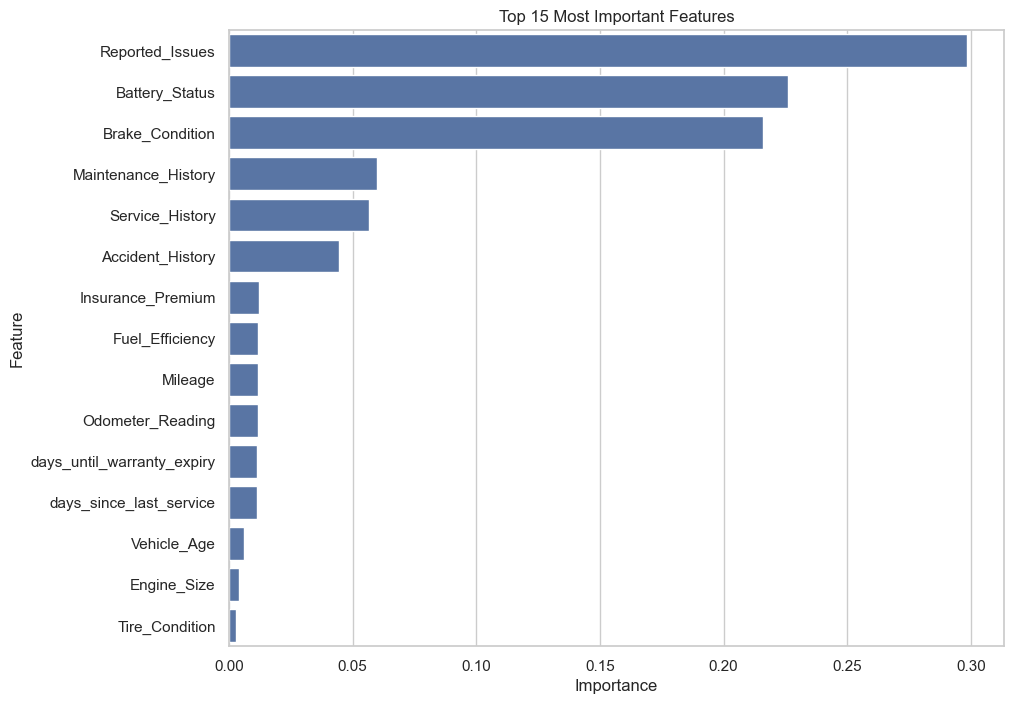

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# --- Step 9: Check Feature Importance ---

# 1. Get feature names from the preprocessor
# We need to combine all the feature names in the correct order
num_features = numeric_features
nom_features = list(preprocessor.named_transformers_['nom'].get_feature_names_out(nominal_features))
ord_features = ordinal_features

# Concatenate all feature names
all_feature_names = num_features + nom_features + ord_features

# 2. Get importances from the Random Forest model
importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

# 3. Plot the top 15 features
print("--- Top 15 Most Important Features (from Random Forest) ---")
print(feature_importance_df.head(15))

plt.figure(figsize=(10, 8))
sns.barplot(
    x='importance',
    y='feature',
    data=feature_importance_df.head(15)
)
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

--- Corrected Data Shapes ---
X_train shape (non-leaky): (40000, 15)
X_test shape (non-leaky): (10000, 15)
Shape of re-processed training data: (40000, 22)

--- Training Random Forest on Corrected Data ---

--- (Corrected) Random Forest Classification Report ---
                       precision    recall  f1-score   support

   No Maintenance (0)       0.20      0.00      0.00      1900
Needs Maintenance (1)       0.81      1.00      0.89      8100

             accuracy                           0.81     10000
            macro avg       0.51      0.50      0.45     10000
         weighted avg       0.69      0.81      0.73     10000


--- (Corrected) Confusion Matrix ---


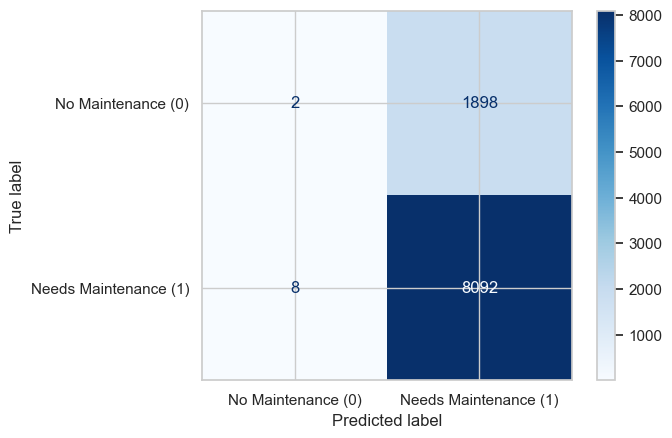

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# --- Step 10: Fix Data Leakage and Re-Train ---

# 1. Define list of leaky features to drop
leaky_features = ['Reported_Issues', 'Brake_Condition', 'Battery_Status', 'Tire_Condition']

# 2. Create the new, non-leaky X and y
# We start from df_processed again
X = df_processed.drop(['Need_Maintenance'] + leaky_features, axis=1)
y = df_processed['Need_Maintenance']

# 3. Split the corrected data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"--- Corrected Data Shapes ---")
print(f"X_train shape (non-leaky): {X_train.shape}")
print(f"X_test shape (non-leaky): {X_test.shape}")

# 4. REDEFINE Column Groups (without leaky features)

# Numeric features
numeric_features = [
    'Mileage', 'Vehicle_Age', 'Engine_Size', 'Odometer_Reading',
    'Insurance_Premium', 'Service_History', 'Accident_History', 'Fuel_Efficiency',
    'days_since_last_service', 'days_until_warranty_expiry'
]

# Nominal (text) features (unchanged)
nominal_features = ['Vehicle_Model', 'Fuel_Type']

# Ordinal (text) features (without leaky ones)
ordinal_features = [
    'Maintenance_History', 'Transmission_Type', 'Owner_Type'
]

# Define the orders for the remaining ordinal features
maintenance_order = ['Poor', 'Average', 'Good']
transmission_order = ['Manual', 'Automatic']
owner_order = ['Third', 'Second', 'First']

# 5. REBUILD the Transformers and Preprocessor

numeric_transformer = StandardScaler()
nominal_transformer = OneHotEncoder(handle_unknown='ignore')
ordinal_transformer = OrdinalEncoder(categories=[
    maintenance_order,
    transmission_order,
    owner_order
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)
    ],
    remainder='passthrough'
)

# 6. RE-APPLY the preprocessor
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Shape of re-processed training data: {X_train_processed.shape}")

# 7. RE-TRAIN the Random Forest model
print("\n--- Training Random Forest on Corrected Data ---")
rf_model_corrected = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model_corrected.fit(X_train_processed, y_train)

# Make predictions
y_pred_rf_corrected = rf_model_corrected.predict(X_test_processed)

# 8. Show the NEW, realistic Classification Report
print("\n--- (Corrected) Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf_corrected, target_names=['No Maintenance (0)', 'Needs Maintenance (1)']))

# 9. Show the NEW Confusion Matrix
print("\n--- (Corrected) Confusion Matrix ---")
cm_corrected = confusion_matrix(y_test, y_pred_rf_corrected)
disp_corrected = ConfusionMatrixDisplay(confusion_matrix=cm_corrected, display_labels=['No Maintenance (0)', 'Needs Maintenance (1)'])
disp_corrected.plot(cmap=plt.cm.Blues)
plt.show()

--- Training Balanced Random Forest on Corrected Data ---

--- (Balanced) Random Forest Classification Report ---
                       precision    recall  f1-score   support

   No Maintenance (0)       0.33      0.00      0.00      1900
Needs Maintenance (1)       0.81      1.00      0.89      8100

             accuracy                           0.81     10000
            macro avg       0.57      0.50      0.45     10000
         weighted avg       0.72      0.81      0.73     10000


--- (Balanced) Confusion Matrix ---


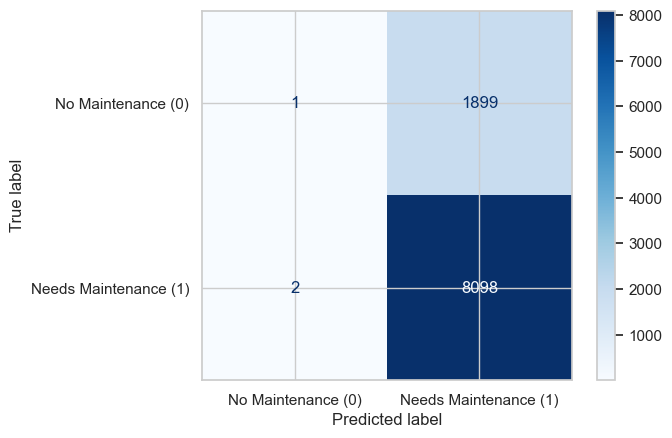

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Step 11: Re-Train Random Forest with Class Weight Balancing ---

print("--- Training Balanced Random Forest on Corrected Data ---")

# We add class_weight='balanced'
rf_model_balanced = RandomForestClassifier(
    random_state=42, 
    n_jobs=-1, 
    class_weight='balanced'
)

# We train on the same non-leaky processed data
rf_model_balanced.fit(X_train_processed, y_train)

# Make predictions
y_pred_rf_balanced = rf_model_balanced.predict(X_test_processed)

# Show the new, balanced report
print("\n--- (Balanced) Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_rf_balanced, target_names=['No Maintenance (0)', 'Needs Maintenance (1)']))

# Show the new, balanced confusion matrix
print("\n--- (Balanced) Confusion Matrix ---")
cm_balanced = confusion_matrix(y_test, y_pred_rf_balanced)
disp_balanced = ConfusionMatrixDisplay(confusion_matrix=cm_balanced, display_labels=['No Maintenance (0)', 'Needs Maintenance (1)'])
disp_balanced.plot(cmap=plt.cm.Blues)
plt.show()

Original training data shape: (40000, 22)
Original training target distribution:
Need_Maintenance
1    32398
0     7602
Name: count, dtype: int64

--- After SMOTE ---
New resampled training data shape: (64796, 22)
New resampled training target distribution:
Need_Maintenance
1    32398
0    32398
Name: count, dtype: int64

--- (SMOTE) Random Forest Classification Report ---
                       precision    recall  f1-score   support

   No Maintenance (0)       0.38      0.02      0.05      1900
Needs Maintenance (1)       0.81      0.99      0.89      8100

             accuracy                           0.81     10000
            macro avg       0.60      0.51      0.47     10000
         weighted avg       0.73      0.81      0.73     10000


--- (SMOTE) Confusion Matrix ---


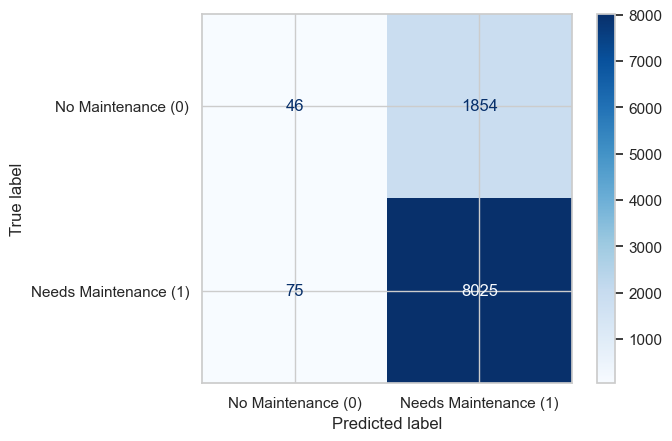

In [12]:
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Step 12: Re-Train with SMOTE-Resampled Data ---

print(f"Original training data shape: {X_train_processed.shape}")
print(f"Original training target distribution:\n{y_train.value_counts()}")

# 1. Initialize SMOTE
#    random_state=42 ensures we get the same results every time
smote = SMOTE(random_state=42)

# 2. Apply SMOTE to the training data *only*
#    NEVER apply SMOTE to your test data!
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("\n--- After SMOTE ---")
print(f"New resampled training data shape: {X_train_smote.shape}")
print(f"New resampled training target distribution:\n{y_train_smote.value_counts()}")

# 3. Train a new Random Forest on the SMOTE'd data
#    (We don't need class_weight anymore, as the data is balanced)
rf_model_smote = RandomForestClassifier(random_state=42, n_jobs=-1)
rf_model_smote.fit(X_train_smote, y_train_smote)

# 4. Make predictions on the *original* (unseen) test set
y_pred_smote = rf_model_smote.predict(X_test_processed)

# 5. Show the new report
print("\n--- (SMOTE) Random Forest Classification Report ---")
print(classification_report(y_test, y_pred_smote, target_names=['No Maintenance (0)', 'Needs Maintenance (1)']))

# 6. Show the new confusion matrix
print("\n--- (SMOTE) Confusion Matrix ---")
cm_smote = confusion_matrix(y_test, y_pred_smote)
disp_smote = ConfusionMatrixDisplay(confusion_matrix=cm_smote, display_labels=['No Maintenance (0)', 'Needs Maintenance (1)'])
disp_smote.plot(cmap=plt.cm.Blues)
plt.show()

Calculated scale_pos_weight: 0.2346

--- Training Balanced XGBoost ---


E:\Projects\Data Analytcs\SmartFleet Predict AI-Driven Vehicle Maintenance System\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:05:52] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- (Balanced) XGBoost Classification Report ---
                       precision    recall  f1-score   support

   No Maintenance (0)       0.26      0.50      0.34      1900
Needs Maintenance (1)       0.85      0.65      0.74      8100

             accuracy                           0.63     10000
            macro avg       0.55      0.58      0.54     10000
         weighted avg       0.74      0.63      0.66     10000


--- (Balanced) XGBoost Confusion Matrix ---


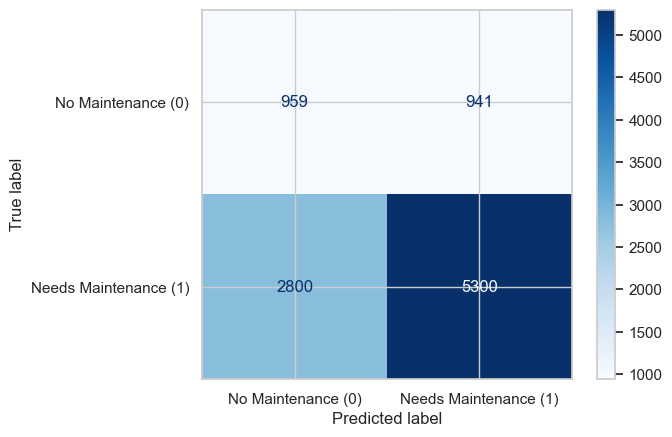

In [13]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# --- Step 13: Final Model Test (XGBoost with scale_pos_weight) ---

# 1. Calculate the scale_pos_weight
#    This is the ratio of negative class (0) to positive class (1)
#    Original training data: 7602 '0's and 32398 '1's
scale_pos_weight = 7602 / 32398
print(f"Calculated scale_pos_weight: {scale_pos_weight:.4f}")

# 2. Train the XGBoost Classifier
#    We use the *original* (non-SMOTE) processed training data
#    We add the scale_pos_weight parameter to handle imbalance
xgb_model_balanced = XGBClassifier(
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

print("\n--- Training Balanced XGBoost ---")
xgb_model_balanced.fit(X_train_processed, y_train)

# 3. Make predictions on the test set
y_pred_xgb_balanced = xgb_model_balanced.predict(X_test_processed)

# 4. Show the Classification Report
print("\n--- (Balanced) XGBoost Classification Report ---")
print(classification_report(y_test, y_pred_xgb_balanced, target_names=['No Maintenance (0)', 'Needs Maintenance (1)']))

# 5. Show the Confusion Matrix
print("\n--- (Balanced) XGBoost Confusion Matrix ---")
cm_xgb = confusion_matrix(y_test, y_pred_xgb_balanced)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No Maintenance (0)', 'Needs Maintenance (1)'])
disp_xgb.plot(cmap=plt.cm.Blues)
plt.show()

In [14]:
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
import joblib

# --- Step 14: Create and Save the Final Model Pipeline ---

# 1. Re-define the ColumnTransformer (preprocessor) from Step 10
#    (We'll just copy the code here for completeness)

# Numeric features
numeric_features = [
    'Mileage', 'Vehicle_Age', 'Engine_Size', 'Odometer_Reading',
    'Insurance_Premium', 'Service_History', 'Accident_History', 'Fuel_Efficiency',
    'days_since_last_service', 'days_until_warranty_expiry'
]
# Nominal (text) features
nominal_features = ['Vehicle_Model', 'Fuel_Type']
# Ordinal (text) features
ordinal_features = ['Maintenance_History', 'Transmission_Type', 'Owner_Type']

# Define the orders
maintenance_order = ['Poor', 'Average', 'Good']
transmission_order = ['Manual', 'Automatic']
owner_order = ['Third', 'Second', 'First']

# Create transformers
numeric_transformer = StandardScaler()
nominal_transformer = OneHotEncoder(handle_unknown='ignore')
ordinal_transformer = OrdinalEncoder(categories=[
    maintenance_order,
    transmission_order,
    owner_order
])

# Create the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('nom', nominal_transformer, nominal_features),
        ('ord', ordinal_transformer, ordinal_features)
    ],
    remainder='passthrough'
)

# 2. Define our final XGBoost model
#    We use the same parameters from Step 13
scale_pos_weight = 7602 / 32398 # (minority / majority)
final_model = XGBClassifier(
    random_state=42, 
    use_label_encoder=False, 
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight
)

# 3. Create the full pipeline
# 
#    This chains the preprocessing and modeling steps together
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', final_model)
])

# 4. Train the *entire* pipeline on the non-leaky training data
print("--- Training Final Pipeline ---")
# We use the X_train and y_train from Step 10
final_pipeline.fit(X_train, y_train)

# 5. Save the pipeline to a file
model_filename = 'smartfleet_model.joblib'
joblib.dump(final_pipeline, model_filename)

print(f"\n--- Model Saved! ---")
print(f"Your complete model pipeline has been saved as: {model_filename}")

--- Training Final Pipeline ---


E:\Projects\Data Analytcs\SmartFleet Predict AI-Driven Vehicle Maintenance System\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [01:05:53] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- Model Saved! ---
Your complete model pipeline has been saved as: smartfleet_model.joblib


Success! Confusion matrix saved as 'confusion_matrix.png'


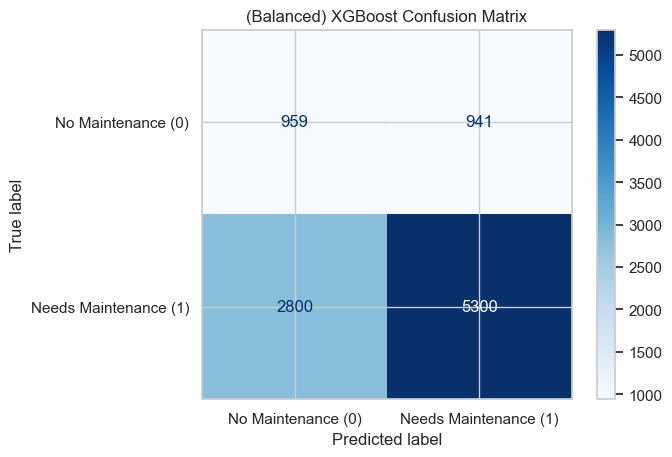

In [15]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# --- Step 15: Save the Final Confusion Matrix Plot ---

# 1. We're using the balanced XGBoost model (xgb_model_balanced)
#    and its predictions (y_pred_xgb_balanced) from Step 13.

# 2. Generate the Confusion Matrix display object
cm_xgb = confusion_matrix(y_test, y_pred_xgb_balanced)
disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=['No Maintenance (0)', 'Needs Maintenance (1)'])

# 3. Plot and SAVE the figure
disp_xgb.plot(cmap=plt.cm.Blues)
plt.title("(Balanced) XGBoost Confusion Matrix")

# This is the new, important line:
plt.savefig('confusion_matrix.png', bbox_inches='tight')

print("Success! Confusion matrix saved as 'confusion_matrix.png'")
